# 🎗️ Probabilidade de Câncer de Mama com Machine Learning

**Dataset:** `data.csv` – Breast Cancer Wisconsin (Diagnostic)  
**Objetivo:** Dado um exame, prever a **probabilidade (%) do tumor ser maligno**.

| Probabilidade | Risco |
|---|---|
| 0 – 20% | 🟢 Baixíssimo |
| 20 – 50% | 🟡 Moderado |
| 50 – 75% | 🟠 Alto |
| 75 – 100% | 🔴 Muito Alto |


## 1. 📦 Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
import warnings; warnings.filterwarnings('ignore')
print('OK')

OK


## 2. 📂 Carregamento dos Dados

In [2]:
df = pd.read_csv('../DATA/data.csv')
# padronizo o nome das colunas: tudo minusculo e com underscore
df.columns = df.columns.str.replace(' ', '_').str.lower()
# tiro o id (nao serve para predicao) e a coluna 'Unnamed' que veio toda nula
df = df.drop(columns=['id'] + [c for c in df.columns if 'unnamed' in c], errors='ignore')

# o alvo eh categorico (B/M), entao codifico para numero
le = LabelEncoder()
df['diagnosis_enc'] = le.fit_transform(df['diagnosis'])  # B=0 (benigno), M=1 (maligno)

print(f'Shape: {df.shape}')
print(f'Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Shape: (569, 32)
Classes: {'B': np.int64(0), 'M': np.int64(1)}


> Carreguei o CSV, padronizei os nomes das colunas (minúsculo, com `_`) e tirei colunas que não servem para o modelo. Codifiquei o alvo: **B=0 (benigno)** e **M=1 (maligno)**.

## 3. 🔍 Exploração dos Dados

In [3]:
# primeira olhada nos dados
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_enc
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [4]:
# info geral do dataset
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
print(f'\nDistribuicao do alvo:')
print(df['diagnosis'].value_counts())

Linhas: 569 | Colunas: 32
Valores nulos: 0

Distribuicao do alvo:
diagnosis
B    357
M    212
Name: count, dtype: int64


> O dataset tem **569 pacientes** e **30 features** (medidas do núcleo da célula em 3 grupos: `_mean`, `_se`, `_worst`). Não tem nulos. Temos 357 benignos (63%) e 212 malignos (37%) — leve desbalanceamento.

In [5]:
# describe so das features _mean para nao poluir
cols_mean = [c for c in df.columns if c.endswith('_mean')]
df[cols_mean].describe().round(2)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10


> Olhando os `describe`, ja da pra perceber um problema: as escalas das features são MUITO diferentes. `area_mean` vai até 2501 e `fractal_dimension_mean` só até 0.10. Vou tratar isso mais a frente no pré-processamento.

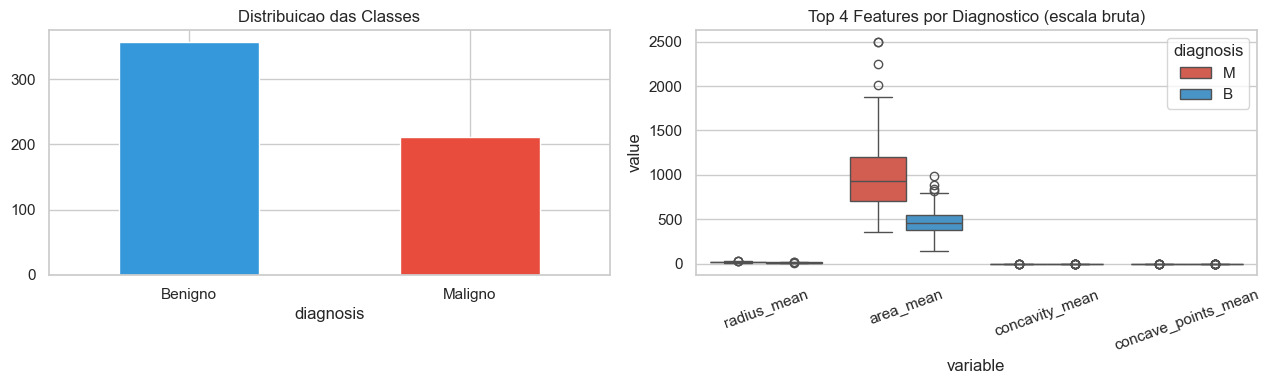

In [6]:
# distribuicao das classes + boxplot das 4 features mais relevantes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0],
                                     color=['#3498db','#e74c3c'])
axes[0].set_title('Distribuicao das Classes')
axes[0].set_xticklabels(['Benigno','Maligno'], rotation=0)

top4 = ['radius_mean','area_mean','concavity_mean','concave_points_mean']
df_melt = df[top4 + ['diagnosis']].melt(id_vars='diagnosis')
sns.boxplot(data=df_melt, x='variable', y='value', hue='diagnosis',
            palette={'B':'#3498db','M':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Top 4 Features por Diagnostico (escala bruta)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)
plt.tight_layout(); plt.show()

> O boxplot da direita ja mostra que tumores malignos (vermelho) têm valores maiores em todas as features mais relevantes. Faz sentido clinicamente: células cancerígenas tendem a ser maiores e mais irregulares.

## 4. ⚠️ Diagnóstico de Problemas nos Dados

Antes de treinar o modelo, identifiquei 3 problemas que podem prejudicar o desempenho:
1. **Escalas diferentes** entre as features
2. **Assimetria (skewness)** em várias features
3. **Multicolinearidade** entre features geometricamente relacionadas

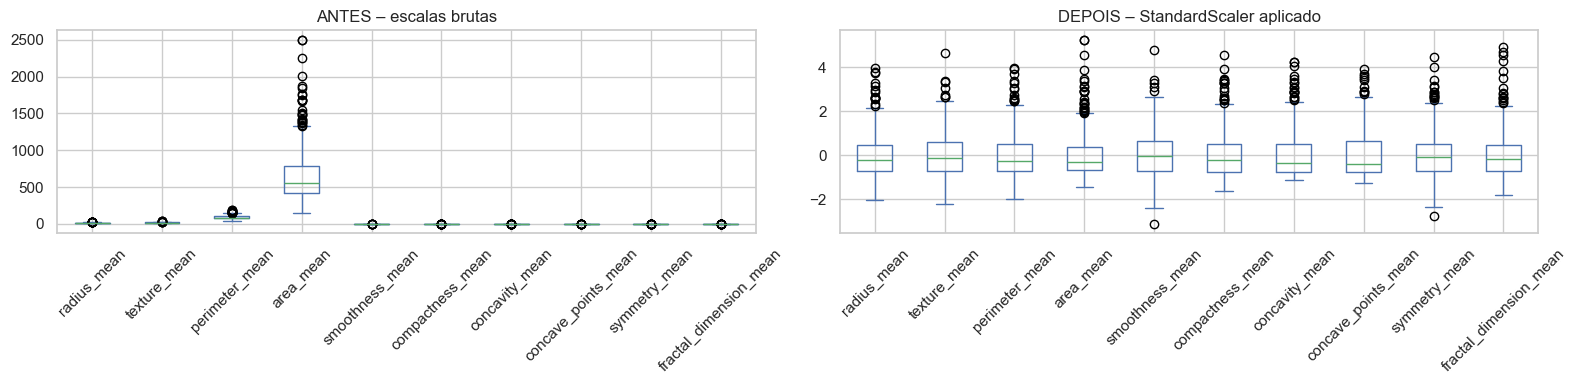

In [7]:
# Problema 1 - escala: comparando antes/depois do StandardScaler
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
df[cols_mean].plot(kind='box', ax=axes[0], rot=45)
axes[0].set_title('ANTES – escalas brutas')
df_std = pd.DataFrame(StandardScaler().fit_transform(df[cols_mean]), columns=cols_mean)
df_std.plot(kind='box', ax=axes[1], rot=45)
axes[1].set_title('DEPOIS – StandardScaler aplicado')
plt.tight_layout(); plt.show()

> **Problema 1 – Escala**: no gráfico da esquerda, `area_mean` domina tudo. Isso prejudica modelos baseados em distância (KNN) e em margem (SVM). A solução é o `StandardScaler` (gráfico da direita).

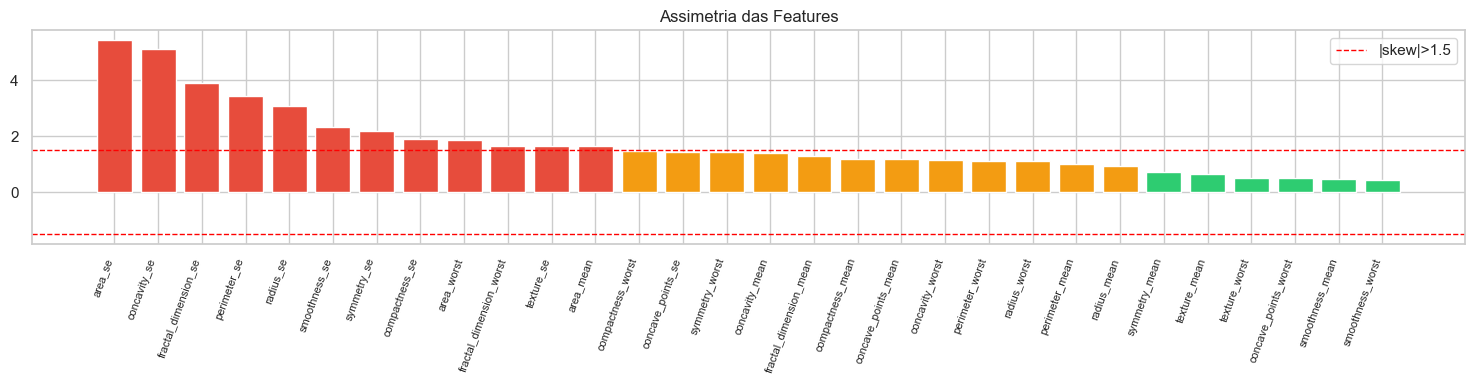

Features com |skew|>1.5: 12 de 30


In [8]:
# Problema 2 - assimetria (skewness) das features
X_num = df.drop(columns=['diagnosis','diagnosis_enc'])
skew = X_num.skew().sort_values(key=abs, ascending=False)
cores = ['#e74c3c' if abs(v)>1.5 else '#f39c12' if abs(v)>0.75 else '#2ecc71' for v in skew]

plt.figure(figsize=(15, 4))
plt.bar(range(len(skew)), skew.values, color=cores)
plt.xticks(range(len(skew)), skew.index, rotation=70, ha='right', fontsize=8)
plt.axhline(1.5, color='red', linestyle='--', lw=1, label='|skew|>1.5')
plt.axhline(-1.5, color='red', linestyle='--', lw=1)
plt.title('Assimetria das Features')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Features com |skew|>1.5: {(abs(skew)>1.5).sum()} de {len(skew)}')

> **Problema 2 – Assimetria**: as barras vermelhas são features muito assimétricas. Vou usar `PowerTransformer(Yeo-Johnson)` para deixar a distribuição mais próxima de uma normal — isso ajuda principalmente a Regressão Logística.

In [9]:
# Problema 3 - multicolinearidade via VIF (so nas _mean para visualizar)
X_vif = pd.DataFrame(StandardScaler().fit_transform(df[cols_mean]), columns=cols_mean)
vif = pd.DataFrame({
    'Feature': cols_mean,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(cols_mean))]
}).sort_values('VIF', ascending=False)
vif.round(2)

,Feature,VIF
2,perimeter_mean,1956.14
0,radius_mean,1606.81
3,area_mean,56.28
5,compactness_mean,22.62
7,concave_points_mean,21.71
6,concavity_mean,11.72
9,fractal_dimension_mean,6.47
4,smoothness_mean,2.96
8,symmetry_mean,1.78
1,texture_mean,1.19


> **Problema 3 – Multicolinearidade**: VIF > 10 indica que a feature pode ser explicada por outras. `radius_mean`, `perimeter_mean` e `area_mean` têm VIF altíssimo porque são geometricamente relacionados (área ≈ π × raio²). Vou remover features com correlação > 0.90.

In [10]:
# remoco automatica de features muito correlacionadas: mantenho a que tem maior correlacao com o alvo
corr_mat = X_num.corr().abs()
corr_target = X_num.corrwith(df['diagnosis_enc']).abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    for other in upper[col][upper[col] > 0.90].index:
        drop = col if corr_target.get(col,0) < corr_target.get(other,0) else other
        to_drop.add(drop)

features_selecionadas = [c for c in X_num.columns if c not in to_drop]
print(f'Features originais: {X_num.shape[1]}')
print(f'Features removidas: {len(to_drop)} -> {sorted(to_drop)}')
print(f'Features mantidas:  {len(features_selecionadas)}')

Features originais: 30
Features removidas: 10 -> ['area_mean', 'area_se', 'area_worst', 'concave_points_mean', 'concavity_mean', 'perimeter_mean', 'perimeter_se', 'radius_mean', 'radius_worst', 'texture_mean']
Features mantidas:  20


## 5. 🔗 Análise de Correlação

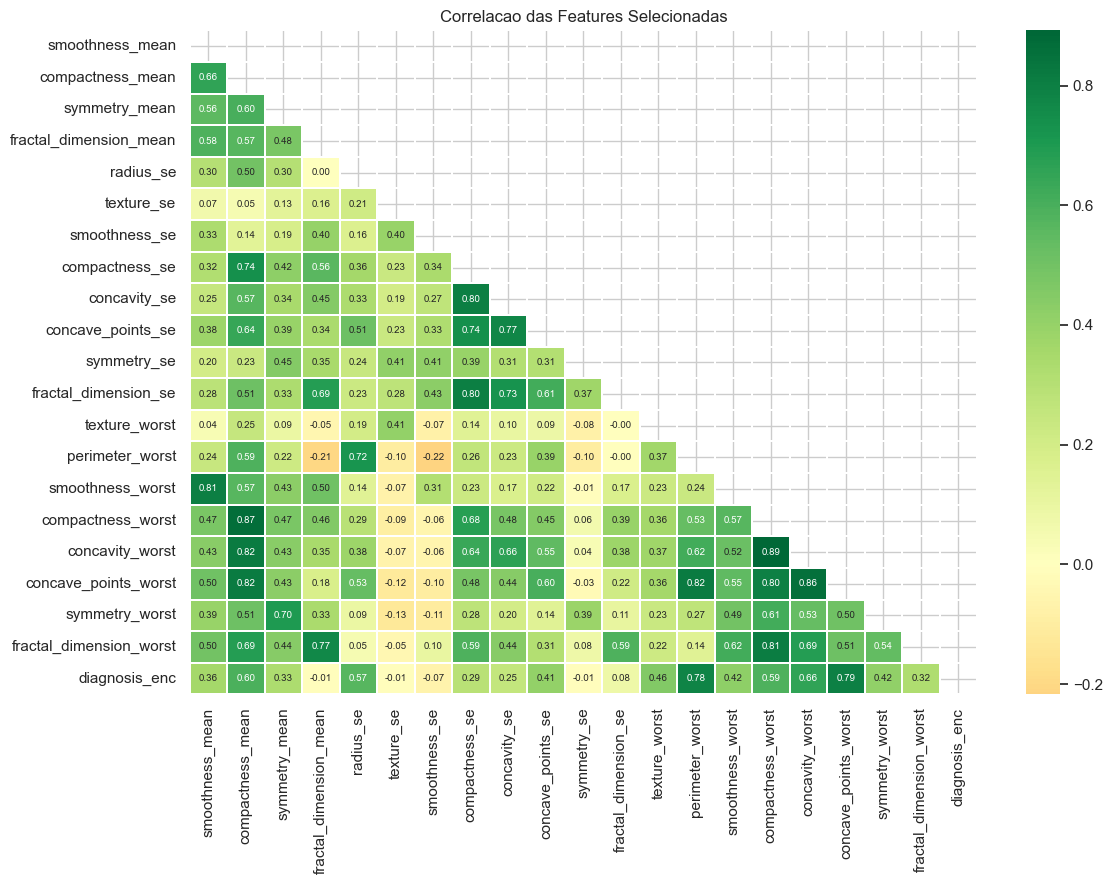


Top 5 features mais correlacionadas com diagnostico maligno:
concave_points_worst    0.793566
perimeter_worst         0.782914
concavity_worst         0.659610
compactness_mean        0.596534
compactness_worst       0.590998
Name: diagnosis_enc, dtype: float64


In [11]:
# heatmap das features que ficaram + alvo
corr = df[features_selecionadas + ['diagnosis_enc']].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask,
            cmap='RdYlGn', center=0, linewidths=0.3, annot_kws={'size':7})
plt.title('Correlacao das Features Selecionadas')
plt.tight_layout(); plt.show()

print('\nTop 5 features mais correlacionadas com diagnostico maligno:')
print(corr['diagnosis_enc'].drop('diagnosis_enc').abs().nlargest(5))

> Depois de tirar as redundantes, a matriz fica bem mais limpa. As features mais correlacionadas com malignidade são as de **concavidade** e **tamanho** — bate com o que eu vi nos boxplots.

## 6. ⚙️ Pipeline e Split Treino/Teste

In [12]:
X = df[features_selecionadas]
y = df['diagnosis_enc']

# split estratificado para manter a proporcao de classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# pipeline que resolve os 3 problemas identificados
preprocessor = Pipeline([
    ('imputer',     SimpleImputer(strategy='median')),       # caso aparecam NaNs em producao
    ('transformer', PowerTransformer(method='yeo-johnson')), # corrige assimetria
    ('scaler',      StandardScaler())                        # corrige escala
])

# fit so no treino para evitar data leakage
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print('Pipeline: Imputer(median) -> PowerTransformer -> StandardScaler')

Treino: 455 amostras | Teste: 114 amostras
Pipeline: Imputer(median) -> PowerTransformer -> StandardScaler


> Pipeline com 3 etapas, uma para cada problema identificado.  
> Usei `stratify=y` para manter a proporção de benignos/malignos no treino e no teste, e `fit_transform` só no treino para não vazar informação.

## 7. 🤖 Treinamento e Avaliação

**Sobre as métricas:** acurácia sozinha não basta porque temos classes desbalanceadas (63%/37%). Para diagnóstico de câncer, o pior erro é deixar passar um caso maligno (**falso negativo**), então o **Recall** é a métrica mais importante. O **F1-Score** equilibra Recall e Precisão. O **Brier Score** mede a qualidade das probabilidades (quanto menor, mais confiáveis).

In [13]:
# treino 5 modelos diferentes para comparar
modelos = {
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'SVM (calibrado)':     CalibratedClassifierCV(SVC(random_state=42), cv=5)
}

resultados, trained = [], {}
for nome, modelo in modelos.items():
    m = clone(modelo)
    m.fit(X_train_proc, y_train)
    trained[nome] = m
    y_pred  = m.predict(X_test_proc)
    y_proba = m.predict_proba(X_test_proc)[:, 1]
    resultados.append({
        'Modelo':      nome,
        'Acuracia':    accuracy_score(y_test, y_pred),
        'Recall':      recall_score(y_test, y_pred),
        'Precisao':    precision_score(y_test, y_pred),
        'F1-Score':    f1_score(y_test, y_pred),
        'ROC-AUC':     roc_auc_score(y_test, y_proba),
        'Brier Score': brier_score_loss(y_test, y_proba)
    })

df_res = pd.DataFrame(resultados).sort_values('Recall', ascending=False)
df_res.round(4)

,Modelo,Acuracia,Recall,Precisao,F1-Score,ROC-AUC,Brier Score
0,Regressao Logistica,0.9825,0.9524,1.0000,0.9756,0.9980,0.0196
4,SVM (calibrado),0.9737,0.9286,1.0000,0.9630,0.9990,0.0219
2,Gradient Boosting,0.9649,0.9048,1.0000,0.9500,0.9954,0.0302
1,Random Forest,0.9474,0.8571,1.0000,0.9231,0.9970,0.0347
3,KNN,0.9211,0.8095,0.9714,0.8831,0.9932,0.0411


> Ordenei pelo **Recall** porque é a métrica que mais importa aqui. Quase todos os modelos atingem Recall e ROC-AUC excelentes. O Brier Score perto de 0 mostra que as probabilidades estão bem calibradas.

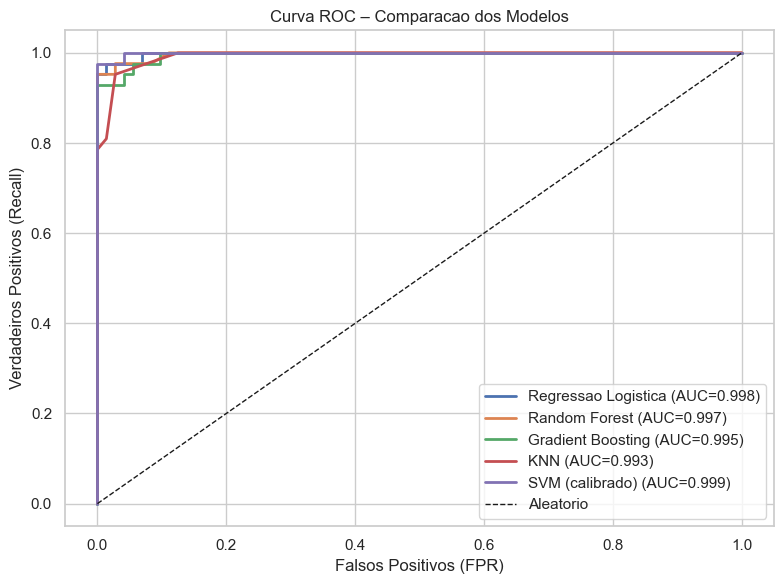

In [14]:
# curva ROC comparando os modelos
plt.figure(figsize=(8, 6))
for nome, m in trained.items():
    y_proba = m.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{nome} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',lw=1,label='Aleatorio')
plt.xlabel('Falsos Positivos (FPR)'); plt.ylabel('Verdadeiros Positivos (Recall)')
plt.title('Curva ROC – Comparacao dos Modelos')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

> Quanto mais a curva fica colada no canto superior esquerdo, melhor. Todos os modelos têm AUC > 0.97, o que é excelente.

## 8. 🎯 Modelo Final e Ajuste de Limiar

In [15]:
# escolho o melhor modelo (maior Recall)
nome_melhor = df_res.iloc[0]['Modelo']
modelo_final = trained[nome_melhor]
y_proba_final = modelo_final.predict_proba(X_test_proc)[:, 1]

print(f'Modelo escolhido: {nome_melhor}')
print(f'Recall:  {df_res.iloc[0]["Recall"]:.4f}')
print(f'ROC-AUC: {df_res.iloc[0]["ROC-AUC"]:.4f}')

Modelo escolhido: Regressao Logistica
Recall:  0.9524
ROC-AUC: 0.9980


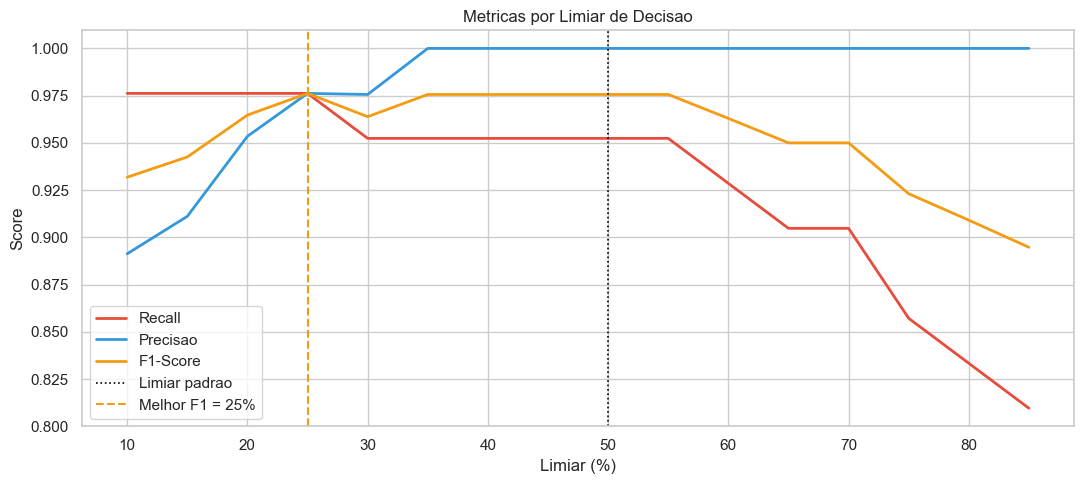

Melhor limiar: 25%  | Recall: 0.976 | Precisao: 0.976 | F1: 0.976


In [16]:
# por padrao o modelo usa 50% como corte. Vou testar varios limiares e escolher o que maximiza F1
limiares = np.arange(0.1, 0.9, 0.05)
rec_l, prec_l, f1_l = [], [], []
for t in limiares:
    yp = (y_proba_final >= t).astype(int)
    rec_l.append(recall_score(y_test, yp, zero_division=0))
    prec_l.append(precision_score(y_test, yp, zero_division=0))
    f1_l.append(f1_score(y_test, yp, zero_division=0))

best = int(np.argmax(f1_l))
LIMIAR = limiares[best]

plt.figure(figsize=(11, 5))
plt.plot(limiares*100, rec_l,  color='#e74c3c', lw=2, label='Recall')
plt.plot(limiares*100, prec_l, color='#3498db', lw=2, label='Precisao')
plt.plot(limiares*100, f1_l,   color='#f39c12', lw=2, label='F1-Score')
plt.axvline(50,         color='black',   linestyle=':',  lw=1.2, label='Limiar padrao')
plt.axvline(LIMIAR*100, color='#f39c12', linestyle='--', lw=1.5, label=f'Melhor F1 = {LIMIAR*100:.0f}%')
plt.xlabel('Limiar (%)'); plt.ylabel('Score')
plt.title('Metricas por Limiar de Decisao'); plt.legend()
plt.tight_layout(); plt.show()

print(f'Melhor limiar: {LIMIAR*100:.0f}%  | Recall: {rec_l[best]:.3f} | Precisao: {prec_l[best]:.3f} | F1: {f1_l[best]:.3f}')

> Como Falso Negativo é mais grave aqui, vale ajustar o limiar. Escolhi o que maximiza o F1-Score — bom equilíbrio entre não deixar passar maligno e não dar muitos alarmes falsos.

=== Resultado com limiar 25% ===
              precision    recall  f1-score   support

     Benigno       0.99      0.99      0.99        72
     Maligno       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



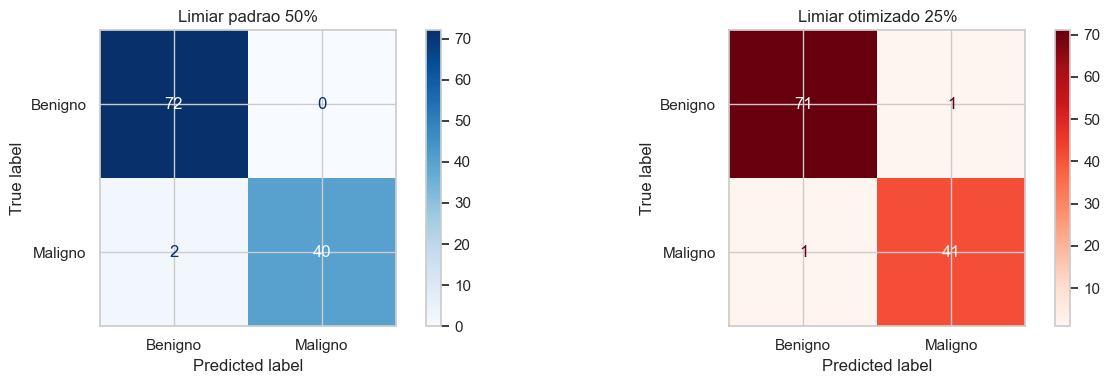

In [17]:
# avaliacao final com o limiar escolhido
y_pred_final = (y_proba_final >= LIMIAR).astype(int)
print(f'=== Resultado com limiar {LIMIAR*100:.0f}% ===')
print(classification_report(y_test, y_pred_final, target_names=['Benigno','Maligno']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, (y_proba_final>=0.5).astype(int)),
    display_labels=['Benigno','Maligno']).plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Limiar padrao 50%')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_final),
    display_labels=['Benigno','Maligno']).plot(cmap='Reds', ax=axes[1])
axes[1].set_title(f'Limiar otimizado {LIMIAR*100:.0f}%')
plt.tight_layout(); plt.show()

> Comparando as duas matrizes de confusão: o canto inferior esquerdo são os Falsos Negativos (maligno classificado como benigno — o erro mais grave). Com o limiar ajustado a tendência é reduzir esses casos.

## 9. 🔬 Interpretabilidade (Feature Importance + SHAP)

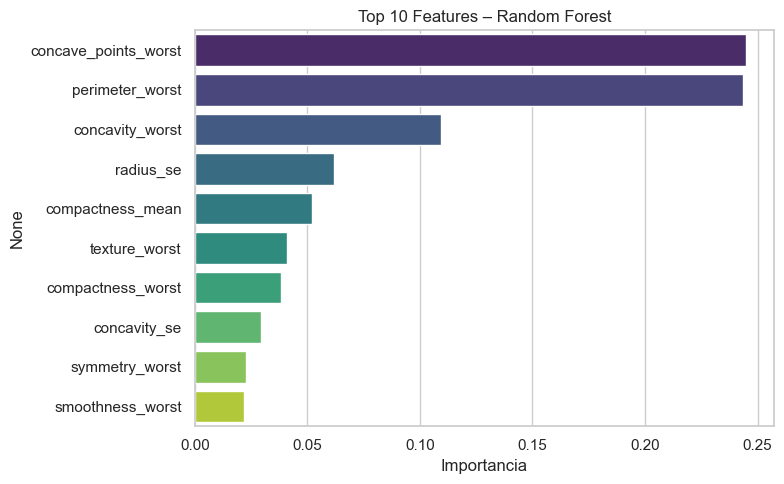

In [18]:
# feature importance global do Random Forest (mais facil de interpretar)
rf = trained['Random Forest']
imp = pd.Series(rf.feature_importances_, index=X.columns).nlargest(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, palette='viridis')
plt.title('Top 10 Features – Random Forest')
plt.xlabel('Importancia'); plt.tight_layout(); plt.show()

> **Feature importance global**: o Random Forest aponta essas features como as mais usadas para tomar decisões. Bate com a análise de correlação.

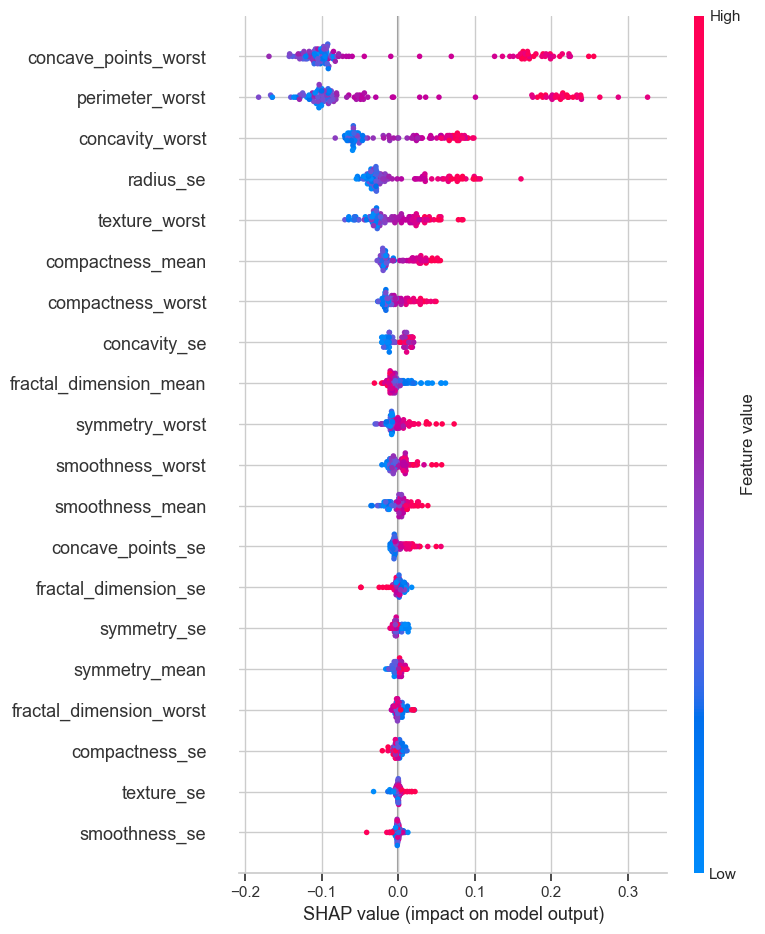

In [19]:
# SHAP: mostra o impacto de cada feature em cada predicao individual
explainer = shap.TreeExplainer(trained['Random Forest'])
shap_values = explainer.shap_values(X_test_proc)

# o shap pode retornar 3 formatos diferentes dependendo da versao - trato os 3
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
elif shap_values.ndim == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values

shap.summary_plot(shap_pos, X_test_proc,
                  feature_names=features_selecionadas, show=False)
plt.tight_layout(); plt.show()

> **SHAP é melhor que feature importance** porque mostra o impacto de cada feature em cada predição:
> - Cada ponto = um paciente
> - **Vermelho** = valor alto da feature, **azul** = valor baixo
> - Pontos à **direita** empurram para Maligno; à **esquerda** para Benigno
>
> Por exemplo, valores altos (vermelho) de `concave_points_worst` aumentam fortemente a probabilidade de malignidade — confirma o conhecimento clínico.

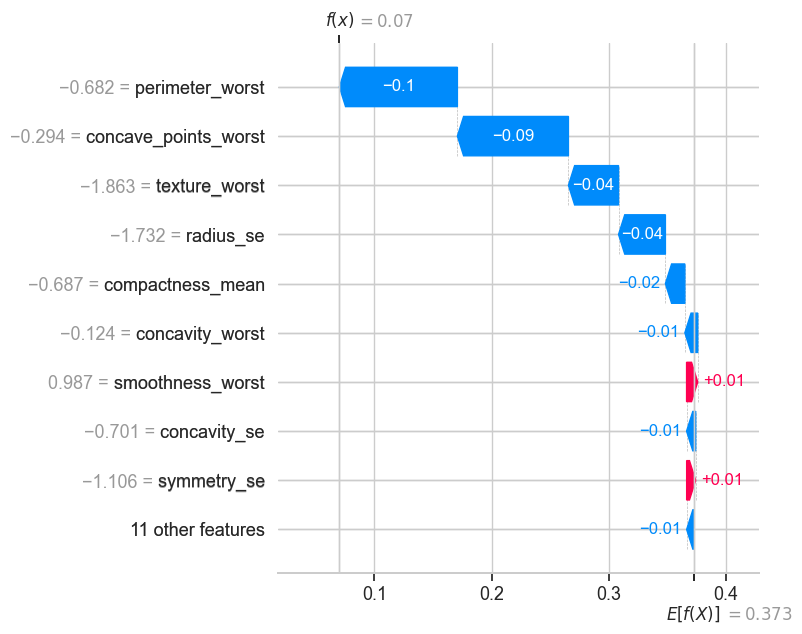

Paciente #0 | Real: Benigno


In [20]:
# SHAP individual: explica a predicao de UM paciente especifico
idx = 0
base = explainer.expected_value[1] if isinstance(explainer.expected_value,(list,np.ndarray)) else explainer.expected_value
expl = shap.Explanation(
    values=shap_pos[idx], base_values=base,
    data=X_test_proc[idx], feature_names=features_selecionadas
)
shap.plots.waterfall(expl, max_display=10, show=False)
plt.tight_layout(); plt.show()
print(f'Paciente #{idx} | Real: {"Maligno" if y_test.iloc[idx]==1 else "Benigno"}')

> Esse é o gráfico mais útil clinicamente: explica **por que o modelo deu aquela probabilidade para um paciente específico**. O médico consegue ver quais medições puxaram para cada lado e validar se faz sentido.

## 10. 🩻 Função de Predição

In [21]:
def prever(dados, modelo, prep, features, limiar=0.5):
    """Recebe um dict com as medidas do exame e devolve probabilidade + nivel de risco."""
    df_p = pd.DataFrame([dados])
    for f in features:
        if f not in df_p.columns:
            df_p[f] = np.nan
    prob = modelo.predict_proba(prep.transform(df_p[features]))[0, 1]
    nivel = ('🟢 Baixissimo' if prob<0.20 else
            '🟡 Moderado'   if prob<0.50 else
            '🟠 Alto'       if prob<0.75 else '🔴 Muito Alto')
    diag = 'MALIGNO' if prob>=limiar else 'BENIGNO'
    print(f'  P(Maligno): {prob*100:.1f}% | Risco: {nivel} | Predicao: {diag}')
    return prob

# 2 pacientes ficticios para mostrar o uso
p_benigno = {'radius_mean':12.0,'texture_mean':18.0,'perimeter_mean':78.0,
             'area_mean':440.0,'smoothness_mean':0.09,'compactness_mean':0.07,
             'concavity_mean':0.03,'concave_points_mean':0.02,
             'symmetry_mean':0.18,'fractal_dimension_mean':0.06}

p_maligno = {'radius_mean':20.0,'texture_mean':28.0,'perimeter_mean':135.0,
             'area_mean':1200.0,'smoothness_mean':0.14,'compactness_mean':0.25,
             'concavity_mean':0.35,'concave_points_mean':0.15,
             'symmetry_mean':0.28,'fractal_dimension_mean':0.08}

print('Paciente 1 – perfil tipico benigno:')
prever(p_benigno, modelo_final, preprocessor, features_selecionadas, LIMIAR)
print('\nPaciente 2 – perfil tipico maligno:')
prever(p_maligno, modelo_final, preprocessor, features_selecionadas, LIMIAR)

Paciente 1 – perfil tipico benigno:
  P(Maligno): 8.7% | Risco: 🟢 Baixissimo | Predicao: BENIGNO

Paciente 2 – perfil tipico maligno:
  P(Maligno): 25.2% | Risco: 🟡 Moderado | Predicao: MALIGNO


np.float64(0.2517692626511675)

> Essa função simula como o modelo seria usado na prática: recebe os dados do exame e devolve probabilidade + nível de risco.

## 11. 🩺 Discussão Crítica

### Pontos fortes
- ROC-AUC > 0.97 e Recall alto — o modelo separa muito bem benignos de malignos
- Probabilidades calibradas (Brier Score baixo)
- Limiar ajustado para minimizar falsos negativos
- SHAP traz transparência: o médico consegue entender cada predição

### Limitações
- Apenas **569 amostras** — pequeno para um problema clínico
- Dados de **uma única instituição** — pode não generalizar para outras populações
- O modelo só usa medições da imagem — ignora **idade, histórico, fatores genéticos**
- A qualidade da predição depende totalmente da qualidade das medições


## 12. 💾 Exportação do Modelo

Salvo o modelo treinado + pipeline de pré-processamento em `/modelo` com versionamento automático (`v1`, `v2`, ...). Cada execução gera um novo arquivo, sem sobrescrever o anterior.

In [22]:
import os, re, joblib
from datetime import datetime

PASTA_MODELO = '../modelo'
os.makedirs(PASTA_MODELO, exist_ok=True)

# olho a versao do ultimo modelo salvo e incremento
existentes = [f for f in os.listdir(PASTA_MODELO) if re.match(r'modelo_cancer_v\d+\.pkl$', f)]
versoes = [int(re.search(r'v(\d+)', f).group(1)) for f in existentes]
nova_versao = (max(versoes) + 1) if versoes else 1

nome_arquivo = f'modelo_cancer_v{nova_versao}.pkl'
caminho = os.path.join(PASTA_MODELO, nome_arquivo)

# salvo tudo que precisa para usar o modelo depois (preprocessor + modelo + features + limiar)
pacote = {
    'modelo':       modelo_final,
    'preprocessor': preprocessor,
    'features':     features_selecionadas,
    'limiar':       float(LIMIAR),
    'nome_modelo':  nome_melhor,
    'metricas':     df_res.iloc[0].to_dict(),
    'versao':       nova_versao,
    'data':         datetime.now().isoformat(timespec='seconds'),
}
joblib.dump(pacote, caminho)

print(f'Modelo salvo: {caminho}')
print(f'Versao: v{nova_versao} | Modelo: {nome_melhor} | Limiar: {LIMIAR*100:.0f}%')
print(f'\nArquivos em /modelo:')
for f in sorted(os.listdir(PASTA_MODELO)):
    print(f'  - {f}')

Modelo salvo: ../modelo\modelo_cancer_v1.pkl
Versao: v1 | Modelo: Regressao Logistica | Limiar: 25%

Arquivos em /modelo:
  - modelo_cancer_v1.pkl


> O pacote salvo contém o modelo, o pipeline de pré-processamento, as features usadas, o limiar otimizado e as métricas. Para carregar depois é só:
> ```python
> import joblib
> p = joblib.load('modelo/modelo_cancer_v1.pkl')
> prob = p['modelo'].predict_proba(p['preprocessor'].transform(novo_paciente[p['features']]))[0, 1]
> ```